In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0

SEED_VALUE = 1234
np.random.seed(SEED_VALUE)
import random
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [2]:
BATCH_SIZE = 8
IMAGE_SIZE = 100

NUM_CHANNELS = 1
NUM_CLASSES = 20
LATENT_DIM = 192

In [3]:
DATASET_PATH = "C:/Users/grego/Documents/NVIDIA DLI/Notebooks/My Notebooks/data/birds-20"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH,"train"),
    validation_split=0.2,
    color_mode='grayscale',
    label_mode = "categorical",
    subset="training",
    seed=SEED_VALUE,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH,"train"),
    validation_split=0.2,
    color_mode='grayscale',
    label_mode = "categorical",
    subset="validation",
    seed=SEED_VALUE,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)


Found 3208 files belonging to 20 classes.
Using 2567 files for training.
Found 3208 files belonging to 20 classes.
Using 641 files for validation.


In [4]:
generator_in_channels = LATENT_DIM + NUM_CLASSES
discriminator_in_channels = NUM_CHANNELS + NUM_CLASSES
print(generator_in_channels, discriminator_in_channels)

212 21


# Building The Models

In [5]:
def freeze_weights(model,backbone_name:str,unfrozen_blocks:list):
    # model.trainable=True

    layer_names = model.get_layer(backbone_name).layers
    for i in range(len(layer_names)):
        exist_flag = False
        for j in unfrozen_blocks:
            if j not in model.get_layer(backbone_name).layers[i].name and not exist_flag:
                model.get_layer(backbone_name).layers[i].trainable = False
            else:
                model.get_layer(backbone_name).layers[i].trainable = True
                exist_flag = True
            
    return model


In [ ]:
inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
base_model = EfficientNetB0(weights='imagenet',input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),include_top=False)(inputs)
base_model.trainable = False
X = layers.GlobalAveragePooling2D()(base_model)
outputs = layers.Dense(1,activation='sigmoid')(X)
discriminator = Model(inputs,outputs,name='discriminator')
discriminator = freeze_weights(discriminator,backbone_name='efficientnetb0',unfrozen_blocks = ['block6','block7'])
discriminator.summary()


Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100, 100, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 4, 4, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1)                 1281      
                                                                 
Total params: 4,050,852
Trainable params: 2,744,861
Non-trainable params: 1,305,991
_________________________________________________________________


In [6]:
discriminator = tf.keras.Sequential(
    [
        tf.keras.layers.InputLayer((IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)),
        layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.GlobalMaxPooling2D(),
        layers.Dense(1,activation='sigmoid'),
    ],
    name="discriminator",
)


In [7]:
generator = tf.keras.Sequential(
    [
        layers.InputLayer((generator_in_channels,)),
        layers.Dense(2 * 2 * generator_in_channels),
        layers.Dropout(0.2),
        layers.Dense(generator_in_channels, use_bias=False),
        layers.Dropout(0.1),
        layers.Dense(25 * 25 * generator_in_channels),
        layers.LeakyReLU(alpha=0.2),
        layers.Reshape((25, 25, generator_in_channels)),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, (7, 7), strides=(2, 1), padding="same", activation="relu"),
        layers.Conv2DTranspose(64, (4, 4), strides=(2, 1), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(256, (5, 5), strides=(1, 1), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(NUM_CHANNELS, (7, 7), padding="same", activation="sigmoid"),
    ],
    name="generator",
)

generator.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 848)               180624    
                                                                 
 dropout (Dropout)           (None, 848)               0         
                                                                 
 dense_2 (Dense)             (None, 212)               179776    
                                                                 
 dropout_1 (Dropout)         (None, 212)               0         
                                                                 
 dense_3 (Dense)             (None, 132500)            28222500  
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 132500)            0         
                                                                 
 reshape (Reshape)           (None, 25, 25, 212)       0 

# CGAN Class

In [8]:
class ConditionalGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        # self.seed_generator = tf.random.Generator.from_seed(SEED_VALUE)
        self.seed_generator = SEED_VALUE
        self.gen_loss_tracker = tf.keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        # Unpack the data.
        real_images, one_hot_labels = data

        # Add dummy dimensions to the labels so that they can be concatenated with
        # the images. This is for the discriminator.
        image_one_hot_labels = one_hot_labels[:, :, None, None]
        
        # image_one_hot_labels = tf.repeat(
        #     image_one_hot_labels, repeats=[IMAGE_SIZE * IMAGE_SIZE]
        # )
        # image_one_hot_labels = tf.reshape(
        #     image_one_hot_labels, (-1, IMAGE_SIZE, IMAGE_SIZE, NUM_CLASSES)
        # )

        # Sample random points in the latent space and concatenate the labels.
        # This is for the generator.
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = tf.concat(
            [random_latent_vectors, one_hot_labels], axis=1
        )

        # Decode the noise (guided by labels) to fake images.
        generated_images = self.generator(random_vector_labels)
        
        # Combine them with real images. Note that we are concatenating the labels
        # with these images here.
        # fake_image_and_labels = tf.concat(
        #     [generated_images, image_one_hot_labels], -1
        # )
        # real_image_and_labels = tf.concat([real_images, image_one_hot_labels], -1)
        combined_images = tf.concat(
            [generated_images, real_images], axis=0
        )

        # Assemble labels discriminating real from fake images.
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0
        )

        # Train the discriminator.
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the latent space.
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = tf.concat(
            [random_latent_vectors, one_hot_labels], axis=1
        )

        # Assemble labels that say "all real images".
        misleading_labels = tf.zeros((batch_size, 1))

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            fake_images = self.generator(random_vector_labels)
            # fake_image_and_labels = tf.concat(
            #     [fake_images, image_one_hot_labels], -1
            # )
            predictions = self.discriminator(fake_images)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Monitor loss.
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {
            "g_loss": self.gen_loss_tracker.result(),
            "d_loss": self.disc_loss_tracker.result(),
        }

In [9]:
cond_gan = ConditionalGAN(
    discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM
)
cond_gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
)

In [10]:
history = cond_gan.fit(train_ds, epochs=10)

Epoch 1/10


c:\Users\grego\.conda\envs\tf28\lib\site-packages\tensorflow\python\util\dispatch.py:1082: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


321/321 [==============================] - 36s 95ms/step - g_loss: 1.5125 - d_loss: 0.4863
Epoch 2/10
321/321 [==============================] - 29s 90ms/step - g_loss: 5.3219 - d_loss: 0.0027
Epoch 3/10
321/321 [==============================] - 29s 90ms/step - g_loss: 6.6319 - d_loss: 6.9944e-04
Epoch 4/10
321/321 [==============================] - 29s 91ms/step - g_loss: 7.8222 - d_loss: 2.0426e-04
Epoch 5/10
321/321 [==============================] - 29s 91ms/step - g_loss: 8.5479 - d_loss: 9.7902e-05
Epoch 6/10
321/321 [==============================] - 29s 91ms/step - g_loss: 9.1625 - d_loss: 5.3103e-05
Epoch 7/10
321/321 [==============================] - 29s 91ms/step - g_loss: 9.7433 - d_loss: 2.9558e-05
Epoch 8/10
321/321 [==============================] - 29s 91ms/step - g_loss: 10.1962 - d_loss: 1.8753e-05
Epoch 9/10
321/321 [==============================] - 29s 91ms/step - g_loss: 10.5768 - d_loss: 1.2801e-05
Epoch 10/10
321/321 [==============================] - 29s 91ms

In [12]:
history.history

{'g_loss': [2.9577078819274902,
  5.377182960510254,
  6.988762855529785,
  8.023019790649414,
  8.682476043701172,
  9.320825576782227,
  9.862557411193848,
  10.295031547546387,
  10.662614822387695,
  10.986236572265625],
 'd_loss': [0.16146939992904663,
  0.0027508032508194447,
  0.0005026402650400996,
  0.000168730053701438,
  8.598680869909003e-05,
  4.560090019367635e-05,
  2.6330735636292957e-05,
  1.703167799860239e-05,
  1.177210833702702e-05,
  8.50796732265735e-06]}

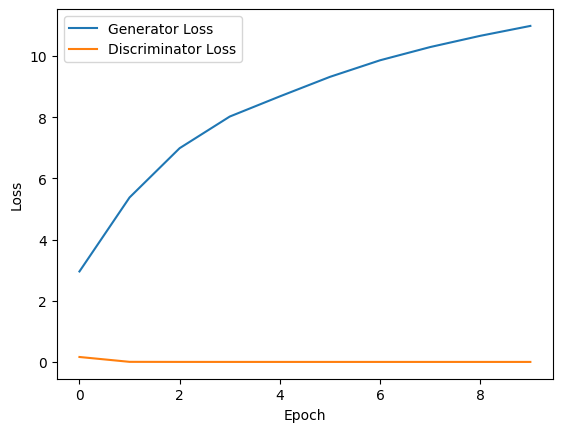

In [13]:
g_loss = history.history['g_loss']
d_loss = history.history['d_loss']
plt.plot(g_loss,label="Generator Loss")
plt.plot(d_loss,label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# FID
https://github.com/jleinonen/keras-fid/tree/master

In [24]:
from src import fid

In [38]:
fd = fid.FrechetInceptionDistance(cond_gan.generator, (0,1)) 

for images,labels in val_ds:
    batch_size = tf.shape(images)[0]
    random_latent_vectors = tf.random.normal(
        shape=(batch_size, LATENT_DIM), seed=SEED_VALUE
    )
    random_vector_labels = tf.concat(
        [random_latent_vectors, labels], axis=1
    )

    gan_fid = fd(images.numpy(), random_vector_labels.numpy(), batch_size=BATCH_SIZE)
    print(gan_fid)
    break


(8, 100, 100, 1)


c:\Users\grego\Documents\SOCS\Teaching Materials\Deep Learning - DTSC6007001\Codes\DL_Materials\notebooks\src\fid.py:35: Warning: Rank deficient covariance matrix, Frechet distance will not be accurate.
  warnings.warn('Rank deficient covariance matrix, '


18693722.94405316


In [ ]:
trained_gen = cond_gan.generator
num_interpolation = 9

# Sample noise for the interpolation.
interpolation_noise = tf.random.normal(shape=(1, LATENT_DIM))
interpolation_noise = tf.repeat(interpolation_noise, repeats=num_interpolation)
interpolation_noise = tf.reshape(interpolation_noise, (num_interpolation, LATENT_DIM))


def interpolate_class(first_number, second_number):
    # Convert the start and end labels to one-hot encoded vectors.
    first_label = tf.keras.utils.to_categorical([first_number], NUM_CLASSES)
    second_label = tf.keras.utils.to_categorical([second_number], NUM_CLASSES)
    first_label = tf.cast(first_label, "float32")
    second_label = tf.cast(second_label, "float32")

    # Calculate the interpolation vector between the two labels.
    percent_second_label = tf.linspace(0, 1, num_interpolation)[:, None]
    percent_second_label = tf.cast(percent_second_label, "float32")
    interpolation_labels = (
        first_label * (1 - percent_second_label) + second_label * percent_second_label
    )

    # Combine the noise and the labels and run inference with the generator.
    noise_and_labels = tf.concat([interpolation_noise, interpolation_labels], 1)
    fake = trained_gen.predict(noise_and_labels)
    return fake


start_class = 2  # @param {type:"slider", min:0, max:9, step:1}
end_class = 6  # @param {type:"slider", min:0, max:9, step:1}

fake_images = interpolate_class(start_class, end_class)

In [15]:
fake_images *= 255.0
converted_images = fake_images.astype(np.uint8)
converted_images = tf.image.resize(converted_images, (96, 96)).numpy().astype(np.uint8)

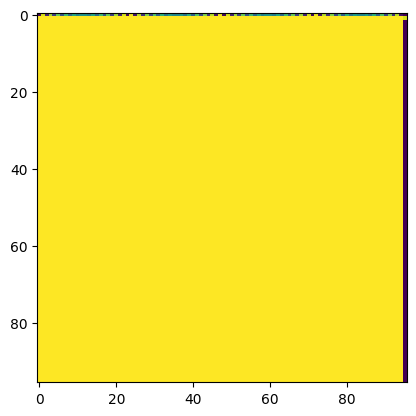

In [19]:
plt.imshow(converted_images[3])